In [1]:
import os
import glob
import numpy as np
import pandas as pd

import torch

from model import INNLightningModule
# from utilities import randmultin
import train

from matplotlib import pyplot as plt
from matplotlib.colors import LogNorm, Normalize
import seaborn as sns
import mplhep as hep

hep.style.use(hep.style.ATLAS)

/opt/conda/envs/torch/lib/python3.11/site-packages/cppyy/__init__.py:374: UserWarning: CPyCppyy API not found (tried: /opt/conda/envs/torch/include/site/python3.11); set CPPYY_API_PATH envar to the 'CPyCppyy' API directory to fix
  warnings.warn("CPyCppyy API not found (tried: %s); "


In [2]:
ckpt_files = glob.glob(f"/root/work/ww-flow/logs/hww_inn_regressor-lep/log/version_0/checkpoints/*.ckpt")
if not ckpt_files:
    raise FileNotFoundError(f"No checkpoint files found in {ckpt_files}")
ckpt_path = ckpt_files[0]  # Use the first checkpoint found
print(f"Using checkpoint: {ckpt_path}")

Using checkpoint: /root/work/ww-flow/logs/hww_inn_regressor-lep/log/version_0/checkpoints/reg-epoch=183-val_loss=2.42.ckpt


In [3]:
def neu_mass(pred_ww, train_features):
	px_w0, py_w0, pz_w0 = pred_ww[:, 0], pred_ww[:, 1], pred_ww[:, 2]
	px_w1, py_w1, pz_w1 = pred_ww[:, 3], pred_ww[:, 4], pred_ww[:, 5]
	mw_0, mw_1 = pred_ww[:, 6], pred_ww[:, 7]
	e_w0, e_w1 = np.sqrt(mw_0**2 + px_w0**2 + py_w0**2 + pz_w0**2), np.sqrt(mw_1**2 + px_w1**2 + py_w1**2 + pz_w1**2)

	lep0_px, lep0_py, lep0_pz, lep0_e = train_features[:, 0], train_features[:, 1], train_features[:, 2], train_features[:, 3] 
	lep1_px, lep1_py, lep1_pz, lep1_e = train_features[:, 4], train_features[:, 5], train_features[:, 6], train_features[:, 7]
	
	def nu_mass_calc(lep_px, lep_py, lep_pz, lep_e, px_w, py_w, pz_w, e_w):
		nu_px = px_w - lep_px
		nu_py = py_w - lep_py
		nu_pz = pz_w - lep_pz
		nu_e = e_w - lep_e
		nu_m2 = nu_e**2 - (nu_px**2 + nu_py**2 + nu_pz**2)
		return nu_m2
	nu0_m2 = nu_mass_calc(lep0_px, lep0_py, lep0_pz, lep0_e, px_w0, py_w0, pz_w0, e_w0)
	nu1_m2 = nu_mass_calc(lep1_px, lep1_py, lep1_pz, lep1_e, px_w1, py_w1, pz_w1, e_w1)

	return nu0_m2, nu1_m2

In [4]:
# Retrieve datamodule used in training
dm = train.main(train=False)
# Get the test dataloader
# `dm.setup()` to resample and standardize the data
# with the fix random seed to ensure no-mixing with training data
dm.setup()
test_loader = dm.test_dataloader()

# Load model from checkpoint
model = INNLightningModule.load_from_checkpoint(ckpt_path)
model.eval() # used to inference -> not for training phase

predictions = np.empty([0, dm.X.shape[1]]) # pred ww
predictions_inputs = np.empty([0, dm.Y.shape[1]]) # pred inputs
true_labels = np.empty([0, dm.X.shape[1]]) # true ww
test_features = np.empty([0, dm.Y.shape[1]]) # lvlv
sample_z = np.empty([0, model.hparams.z_dim]) # sampled z
predictions_z = np.empty([0, model.hparams.z_dim]) # predicted z

# Inference loop
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
with torch.no_grad():
    for batch in test_loader:
        batch_ww, batch_lvlv = batch
        cond = batch_lvlv[:, 10:]  # conditioning variables
        batch_lvlv = batch_lvlv[:, :10]
        cond = cond.to(device)
        batch_ww = batch_ww.to(device)
        batch_lvlv = batch_lvlv.to(device)
        _z_like_tensor = torch.randn(batch_lvlv.shape[0], model.hparams.z_dim, device=device)
        # z_sample = randmultin(_z_like_tensor, device=device)
        z_sample = torch.randn_like(_z_like_tensor) # Gaussian prior
        yz = torch.cat([batch_lvlv.to(device), z_sample.to(device)], dim=1)
        lvlv_pred = model(batch_ww, cond, reverse=False) # the prediction gives the inputs (y, z)
        ww_pred = model(yz, cond, reverse=True)
        z_pred = lvlv_pred[1] # predicted z
        
        # manual inverse stdscaler transform
        mean_X, std_X = torch.tensor(dm.std_ds.scaler_X.mean_, device=device, dtype=torch.float32), torch.tensor(dm.std_ds.scaler_X.scale_, device=device, dtype=torch.float32)
        mean_Y, std_Y = torch.tensor(dm.std_ds.scaler_Y.mean_, device=device, dtype=torch.float32), torch.tensor(dm.std_ds.scaler_Y.scale_, device=device, dtype=torch.float32)
        ww_pred = ww_pred[:, :model.inn.x_dim] * std_X + mean_X
        ww = batch_ww * std_X + mean_X
        lvlv = batch_lvlv * std_Y[:10] + mean_Y[:10]
        lvlv_pred = lvlv_pred[0] * std_Y[:10] + mean_Y[:10] # don't include z

        # Store results
        predictions = np.append(predictions, ww_pred.cpu().numpy(), axis=0)
        true_labels = np.append(true_labels, ww.cpu().numpy(), axis=0)
        test_features = np.append(test_features[:, :10], lvlv.cpu().numpy(), axis=0)
        predictions_inputs = np.append(predictions_inputs[:, :10], lvlv_pred.cpu().numpy(), axis=0)
        sample_z = np.append(sample_z, z_sample.cpu().numpy(), axis=0)
        predictions_z = np.append(predictions_z, z_pred.cpu().numpy(), axis=0)

print("Inference completed.")
print(f"Test features shape: {test_features.shape}")
print(f"Predictions shape: {predictions.shape}")
print(f"True labels shape: {true_labels.shape}")

Evaluation mode, loading checkpoints...
Training objects shape: (376985, 32)
Target objects shape: (376985, 4)
Removed 117 rows with NaN or infinite values
Using 2 workers in data loading.
Loading model from checkpoint for evaluation... return datamodule
Inference completed.
Test features shape: (3768, 10)
Predictions shape: (3768, 4)
True labels shape: (3768, 4)


In [5]:
# # Find all lightning_logs/version_* directories
# log_dirs = glob.glob("logs/hww_inn_regressor-lep/log/version_*")
# if not log_dirs:
#     print("No logs found.")
# else:
#     # Select the largest version number (latest run)
#     latest_log = max(log_dirs, key=lambda x : int(os.path.basename(x).split("_")[1]))
#     metrics_path = os.path.join(latest_log, "metrics.csv")
#     if not os.path.exists(metrics_path):
#         print(f"No metrics.csv found in {latest_log}")
#     else:
#         # Read metrics
#         df = pd.read_csv(metrics_path)

#         # Remove rows with NaN in train_loss or val_loss
#         df_clean = df.copy()
#         if "train_loss" in df_clean.columns:
#             df_clean_train = df_clean[df_clean["train_loss"].notna()]
#         if "val_loss" in df_clean.columns:
#             df_clean_val = df_clean[df_clean["val_loss"].notna()]

#         # Create subplots for better visualization
#         fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        
#         # Plot 1: Total Loss
#         axes[0, 0].plot(df_clean_train["epoch"][3:], df_clean_train["train_loss"][3:], label="Train Loss", color='blue')
#         axes[0, 0].plot(df_clean_val["epoch"][3:], df_clean_val["val_loss"][3:], label="Val Loss", color='red')
#         axes[0, 0].set_xlabel("Epoch")
#         axes[0, 0].set_ylabel("Loss")
#         axes[0, 0].set_title("Total Loss")
#         axes[0, 0].legend()
#         axes[0, 0].grid(True)
#         # axes[0, 0].set_yscale('log')
        
#         # Plot 2: L_y (reconstruction loss)
#         axes[0, 1].plot(df_clean_train["epoch"][3:], df_clean_train["L_y"][3:], label="Train L_y", color='blue')
#         axes[0, 1].plot(df_clean_val["epoch"][3:], df_clean_val["val_L_y"][3:], label="Val L_y", color='red')
#         axes[0, 1].set_xlabel("Epoch")
#         axes[0, 1].set_ylabel("L_y")
#         axes[0, 1].set_title("Reconstruction Loss (L_y)")
#         axes[0, 1].legend()
#         axes[0, 1].grid(True)
#         # axes[0, 1].set_yscale('log')
        
#         # Plot 3: L_z (latent space loss)
#         axes[0, 2].plot(df_clean_train["epoch"][3:], df_clean_train["L_z"][3:], label="Train L_z", color='blue')
#         axes[0, 2].plot(df_clean_val["epoch"][3:], df_clean_val["val_L_z"][3:], label="Val L_z", color='red')
#         axes[0, 2].set_xlabel("Epoch")
#         axes[0, 2].set_ylabel("L_z")
#         axes[0, 2].set_title("Latent Space Loss (L_z)")
#         axes[0, 2].legend()
#         axes[0, 2].grid(True)
#         # axes[0, 2].set_yscale('log')
        
#         # Plot 4: L_x (input reconstruction loss)
#         axes[1, 0].plot(df_clean_train["epoch"][3:], df_clean_train["L_x"][3:], label="Train L_x", color='blue')
#         axes[1, 0].plot(df_clean_val["epoch"][3:], df_clean_val["val_L_x"][3:], label="Val L_x", color='red')
#         axes[1, 0].set_xlabel("Epoch")
#         axes[1, 0].set_ylabel("L_x")
#         axes[1, 0].set_title("Input Reconstruction Loss (L_x)")
#         axes[1, 0].legend()
#         axes[1, 0].grid(True)
#         # axes[1, 0].set_yscale('log')
        
#         # Plot 5: L_pad (padding loss)
#         axes[1, 1].plot(df_clean_train["epoch"][3:], df_clean_train["L_pad"][3:], label="Train L_pad", color='blue')
#         axes[1, 1].plot(df_clean_val["epoch"][3:], df_clean_val["val_L_pad"][3:], label="Val L_pad", color='red')
#         axes[1, 1].set_xlabel("Epoch")
#         axes[1, 1].set_ylabel("L_pad")
#         axes[1, 1].set_title("Padding Loss (L_pad)")
#         axes[1, 1].legend()
#         axes[1, 1].grid(True)
#         # axes[1, 1].set_yscale('log')
        
#         plt.tight_layout()
#         plt.show()
        
#         # Print final loss values for analysis
#         print(f"\nFinal Training Losses (Epoch {df_clean_train['epoch'].iloc[-1]}):")
#         print(f"  Total Loss: {df_clean_train['train_loss'].iloc[-1]:.6f}")
#         print(f"  L_y: {df_clean_train['L_y'].iloc[-1]:.6f}")
#         print(f"  L_z: {df_clean_train['L_z'].iloc[-1]:.6f}")
#         print(f"  L_x: {df_clean_train['L_x'].iloc[-1]:.6f}")
#         print(f"  L_pad: {df_clean_train['L_pad'].iloc[-1]:.6f}")
        
#         print(f"\nFinal Validation Losses:")
#         print(f"  Total Loss: {df_clean_val['val_loss'].iloc[-1]:.6f}") 
#         print(f"  L_y: {df_clean_val['val_L_y'].iloc[-1]:.6f}")
#         print(f"  L_z: {df_clean_val['val_L_z'].iloc[-1]:.6f}")
#         print(f"  L_x: {df_clean_val['val_L_x'].iloc[-1]:.6f}")
#         print(f"  L_pad: {df_clean_val['val_L_pad'].iloc[-1]:.6f}")

In [6]:
# plt.plot(df_clean_train["epoch"][3:], df_clean_train["L_W"][3:], label="Train L_W", color='blue')
# plt.plot(df_clean_val["epoch"][3:], df_clean_val["val_L_W"][3:], label="Val L_W", color='red')
# plt.xlabel("Epoch")
# plt.ylabel("L_W")
# plt.title("Padding Loss (L_W)")
# # plt.semilogy()
# plt.legend()
# plt.grid(True)
# plt.show()

In [7]:
# plt.plot(df_clean_train["epoch"][3:], df_clean_train["L_y_mmd"][3:], label="Train L_y_mmd", color='blue')
# plt.plot(df_clean_val["epoch"][3:], df_clean_val["val_L_y_mmd"][3:], label="Val L_y_mmd", color='red')
# plt.xlabel("Epoch")
# plt.ylabel("L_y_mmd")
# plt.title("L_y_mmd")
# # plt.semilogy()
# plt.legend()
# plt.grid(True)
# plt.show()

In [8]:
# plt.plot(df_clean_train["epoch"][3:], df_clean_train["L_neu_mass"][3:], label="Train L_neu_mass", color='blue')
# plt.plot(df_clean_val["epoch"][3:], df_clean_val["val_L_neu_mass"][3:], label="Val L_neu_mass", color='red')
# plt.xlabel("Epoch")
# plt.ylabel("L_neu_mass")
# plt.title("Padding Loss (L_neu_mass)")
# plt.legend()
# plt.grid(True)
# plt.semilogy()
# plt.show()

In [9]:
def pt(px, py):
    return np.sqrt(np.square(px) + np.square(py))


def eta(px, py, pz):
    pt = np.sqrt(np.square(px) + np.square(py))
    return np.arcsinh(np.divide(pz, pt))


def phi(px, py):
    return np.arctan2(py, px)


def rmse(x, y):
    return np.sqrt(np.mean((x - y) ** 2, axis=0))

In [10]:
# def plot_1d_hist(pred, truth, name, bins_edges=np.linspace(-200, 200, 51), unit="GeV", color="black", savepath=None):
#     plt.hist(pred, bins=bins_edges, linewidth=2, color="red", histtype="step", label="Pred")
#     plt.hist(truth, bins=bins_edges, linewidth=2, color="blue", histtype="step", label="True")
#     plt.legend()
#     plt.xlabel(unit, loc="right")
#     plt.ylabel("Events", loc="top")
#     plt.title(name, loc="right")
    
#     txt = hep.atlas.label("Internal Simulation", data=True, loc=2, rlabel="")
#     txt[0].set_color(color)
#     txt[1].set_color(color)
#     plt.tick_params(axis="both", which="major", pad=10)
#     if savepath is not None:
#         plt.savefig(savepath, bbox_inches="tight")
#     plt.show()
# def plot_2d_hist(pred, truth, name, bins_edges=np.linspace(-200, 200, 51), log=False, unit="GeV", color="black", vmax=5e3, savepath=None):
#     if log:
#         norm = LogNorm(vmin=1, vmax=vmax)
#         plt.hist2d(pred, truth, bins=[bins_edges, bins_edges], cmap="viridis", norm=norm)
#     else:
#         plt.hist2d(pred, truth, bins=[bins_edges, bins_edges], cmap="viridis", vmin=1, vmax=vmax)
#     plt.xlabel(f"Pred [{unit}]")
#     plt.ylabel(f"True [{unit}]")
#     plt.title(f"{name}"+f" with RMSE: {rmse(pred, truth):.2f}", loc="right")
#     txt = hep.atlas.label("Internal Simulation", data=True, loc=2, rlabel="")
#     txt[0].set_color(color)
#     txt[1].set_color(color)
#     plt.tick_params(axis="both", which="major", pad=10) 
#     plt.colorbar(label="Events")
#     plt.gca().set_aspect("equal", adjustable="box")  # Make plot square
#     if savepath is not None:
#         plt.savefig(savepath, bbox_inches="tight")
#     plt.show()

In [11]:
def rel_err_func(a, b):
    if  np.isnan(a).any() or np.isnan(b).any():
        print("Warning: NaN values detected in input arrays.")
    if (np.any(b == 0)):
        print("Warning: Zero values detected in denominator array.")
    mask = ~np.isnan(a) & ~np.isnan(b) & (b != 0)
    return (a[mask] - b[mask]) / b[mask]

def err_bounds(x, rel_err=0.2, offset=5.0):
    delta = rel_err * np.abs(x) + offset
    upper = x + delta
    lower = x - delta
    return upper, lower

def rmse(a, b):
	return np.sqrt(np.mean((a - b) ** 2))

In [12]:
def plot_1d_hist(pred, truth, name, bins_edges=np.linspace(-200, 200, 51), unit="GeV", color="black", savepath=None):
    plt.hist(pred, bins=bins_edges, linewidth=2, color="red", histtype="step", label="Pred")
    plt.hist(truth, bins=bins_edges, linewidth=2, color="blue", histtype="step", label="True")
    plt.legend()
    plt.xlabel(unit, loc="right")
    plt.ylabel("Events", loc="top")
    plt.title(name, loc="right")
    
    txt = hep.atlas.label("Internal Simulation", data=True, loc=2, rlabel="")
    txt[0].set_color(color)
    txt[1].set_color(color)
    plt.tick_params(axis="both", which="major", pad=10)
    if savepath is not None:
        plt.savefig(savepath, bbox_inches="tight")
    plt.show()
def plot_2d_hist(pred, truth, name, bins_edges=np.linspace(-200, 200, 51), log=False, unit="GeV", color="black", vmax=1e3, offset=10.0, savepath=None):
    err = 0.2
    cor_mask = np.abs(rel_err_func(pred, truth)) <= err # set 20% relative error cut
    if log:
        norm = LogNorm(vmin=1, vmax=vmax)
        plt.hist2d(pred, truth, bins=[bins_edges, bins_edges], cmap="viridis", norm=norm)
    else:
        plt.hist2d(pred, truth, bins=[bins_edges, bins_edges], cmap="viridis", vmin=1, vmax=vmax)
        
    # Plot error guides aligned with bin edges
    upper, lower = err_bounds(bins_edges, rel_err=err, offset=offset)
    plt.plot(upper, bins_edges, color="gainsboro", linestyle="-", label=r"$\pm 20\% offset$")
    plt.plot(bins_edges, bins_edges, color="gainsboro", linestyle="--")
    plt.plot(lower, bins_edges, color="gainsboro", linestyle="-")
    
    plt.xlabel(f"Pred [{unit}]")
    plt.ylabel(f"True [{unit}]")
    plt.title(f"{name}"+f" with RMSE: {rmse(pred, truth):.2f}", loc="right")
    print(f"Rel err < 20%: {100*np.sum(cor_mask)/len(truth):.2f} %")
    
    txt = hep.atlas.label("Internal Simulation", data=True, loc=2, rlabel="")
    txt[0].set_color(color)
    txt[1].set_color(color)
    plt.tick_params(axis="both", which="major", pad=10) 
    plt.colorbar(label="Events")
    plt.gca().set_aspect("equal", adjustable="box")  # Make plot square
    if savepath is not None:
        plt.savefig(savepath, bbox_inches="tight")
    plt.show()
    # if log:
    #     plt.hist2d(pred[cor_mask], truth[cor_mask], bins=[bins_edges, bins_edges], cmap="viridis", norm=norm)
    # else:
    #     plt.hist2d(pred[cor_mask], truth[cor_mask], bins=[bins_edges, bins_edges], cmap="viridis", vmin=1, vmax=vmax)
    # # Plot error guides aligned with bin edges
    # upper, lower = err_bounds(bins_edges, rel_err=err)
    # plt.plot(upper, bins_edges, color="red", linestyle="-", label=r"$\pm 20\% offset$")
    # plt.plot(lower, bins_edges, color="red", linestyle="-")
    # plt.xlabel(f"Pred [{unit}]")
    # plt.ylabel(f"True [{unit}]")
    # plt.title(f"{name} (Rel err < 20%)"+f" with RMSE: {rmse(pred[cor_mask], truth[cor_mask]):.2f}", loc="right")
    # txt = hep.atlas.label("Internal Simulation", data=True, loc=2, rlabel="")
    # txt[0].set_color(color)
    # txt[1].set_color(color)
    # plt.tick_params(axis="both", which="major", pad=10) 
    # plt.colorbar(label="Events")
    # plt.gca().set_aspect("equal", adjustable="box")  # Make plot square
    # # if savepath is not None:
    # #     plt.savefig(savepath, bbox_inches="tight")
    # plt.show()

In [13]:
# nu0_mass2, nu1_mass2 = neu_mass(predictions, test_features)
# # neu0_mask = nu0_mass2 > 0
# # neu1_mask = nu1_mass2 > 0
# neu0_mask = np.isfinite(nu0_mass2)
# neu1_mask = np.isfinite(nu1_mass2)
# neu_mask = neu0_mask & neu1_mask
# print(f"Number of events with physical neutrino masses: {np.sum(neu_mask)}")
# print(f"Total number of events: {len(nu0_mass2)}")
# print(f"Fraction of events with physical neutrino masses: {np.sum(neu_mask)/len(nu0_mass2):.4f}")

In [14]:
true_lep0_px = test_features[..., 0]
true_lep0_py = test_features[..., 1]
true_lep0_pz = test_features[..., 2]
true_lep0_e = test_features[..., 3]
true_lep1_px = test_features[..., 4]
true_lep1_py = test_features[..., 5]
true_lep1_pz = test_features[..., 6]
true_lep1_e = test_features[..., 7]
# true_met_px = test_features[..., 8]
# true_met_py = test_features[..., 9]

pred_lep0_px = predictions_inputs[..., 0]
pred_lep0_py = predictions_inputs[..., 1]
pred_lep0_pz = predictions_inputs[..., 2]
pred_lep0_e = predictions_inputs[..., 3]
pred_lep1_px = predictions_inputs[..., 4]
pred_lep1_py = predictions_inputs[..., 5]
pred_lep1_pz = predictions_inputs[..., 6]
pred_lep1_e = predictions_inputs[..., 7]
# pred_met_px = predictions_inputs[..., 8]
# pred_met_py = predictions_inputs[..., 9]

true_z = sample_z
pred_z = predictions_z

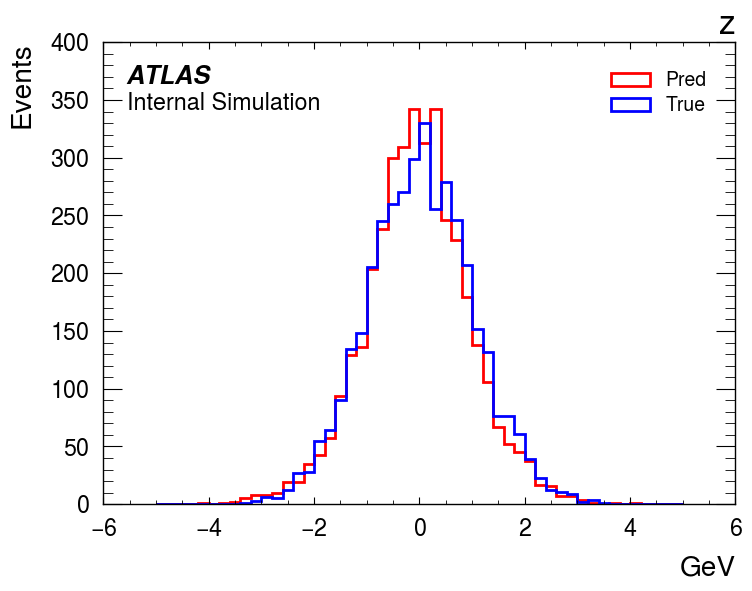

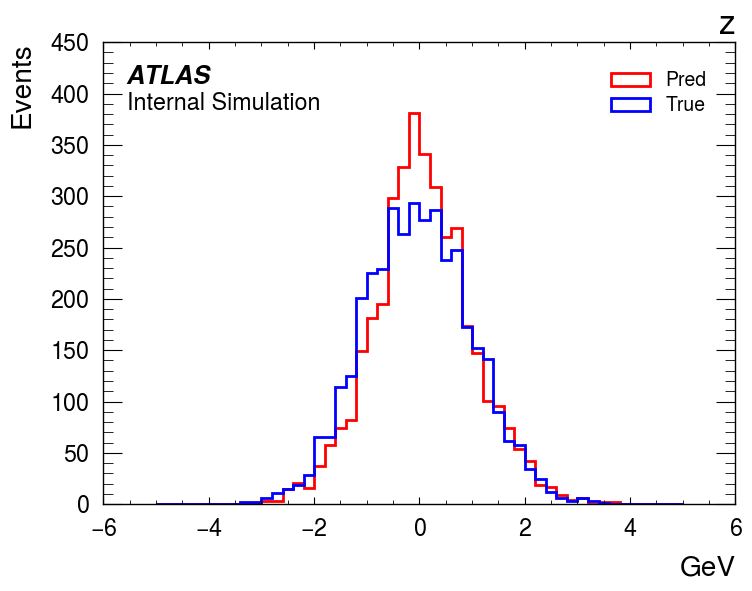

In [15]:
plot_1d_hist(pred_z[..., 0], true_z[..., 0], "z", bins_edges=np.linspace(-5, 5, 51))
plot_1d_hist(pred_z[..., -2], true_z[..., -2], "z", bins_edges=np.linspace(-5, 5, 51))

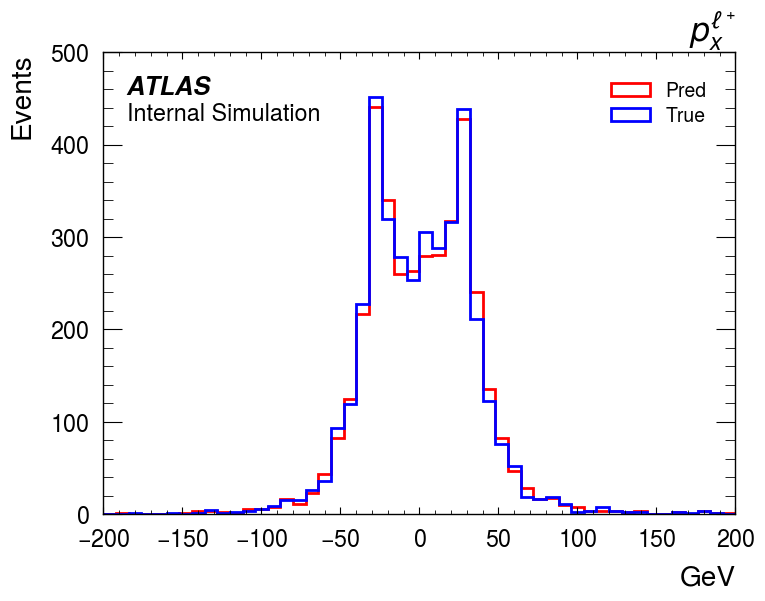

Rel err < 20%: 75.64 %


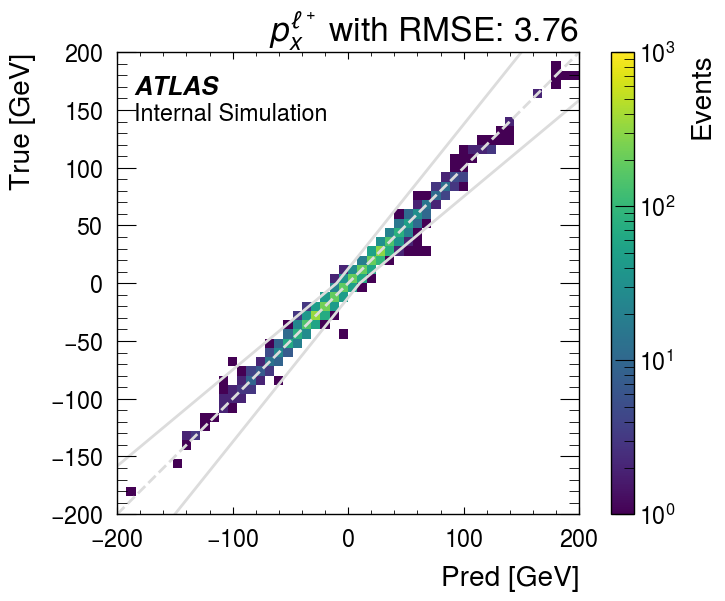

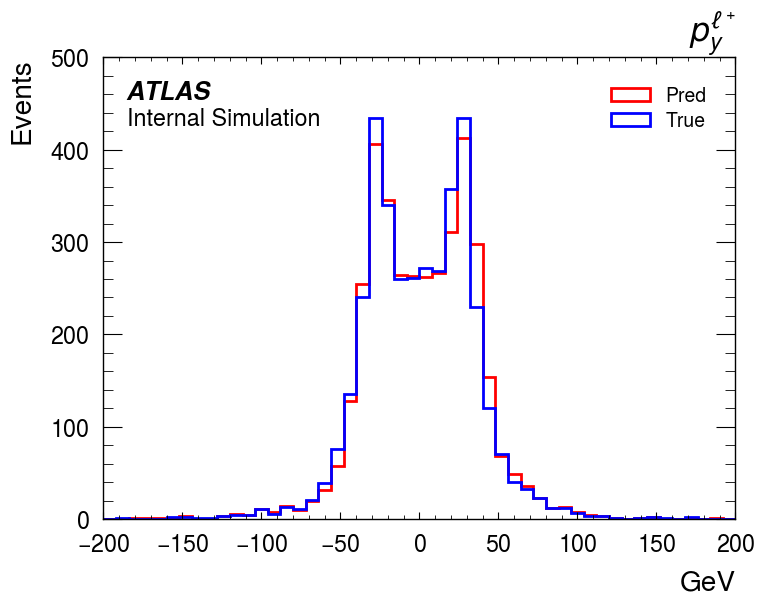

Rel err < 20%: 77.04 %


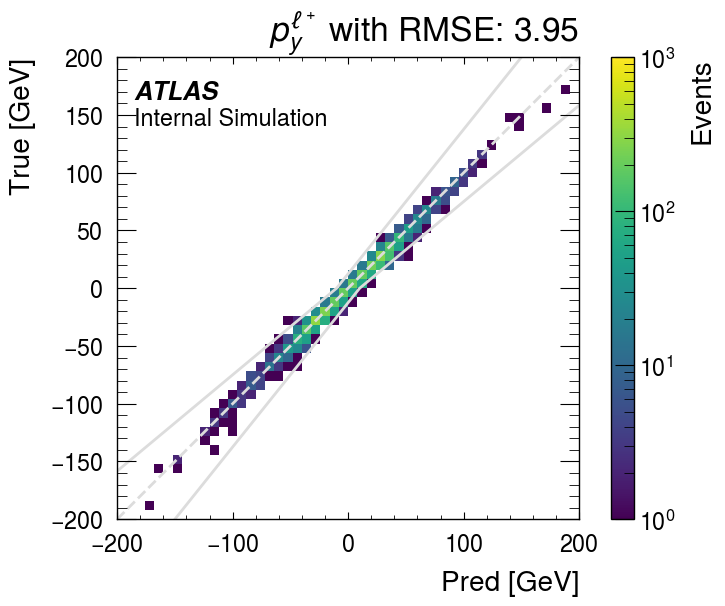

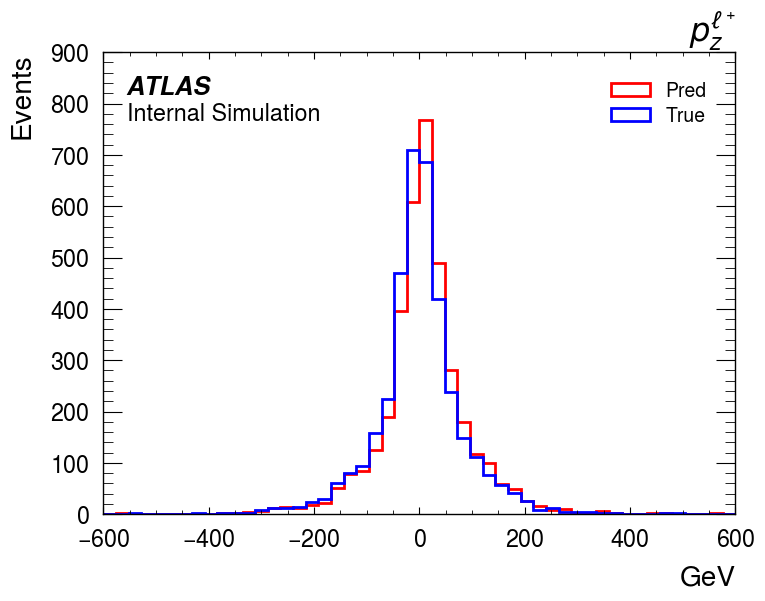

Rel err < 20%: 48.49 %


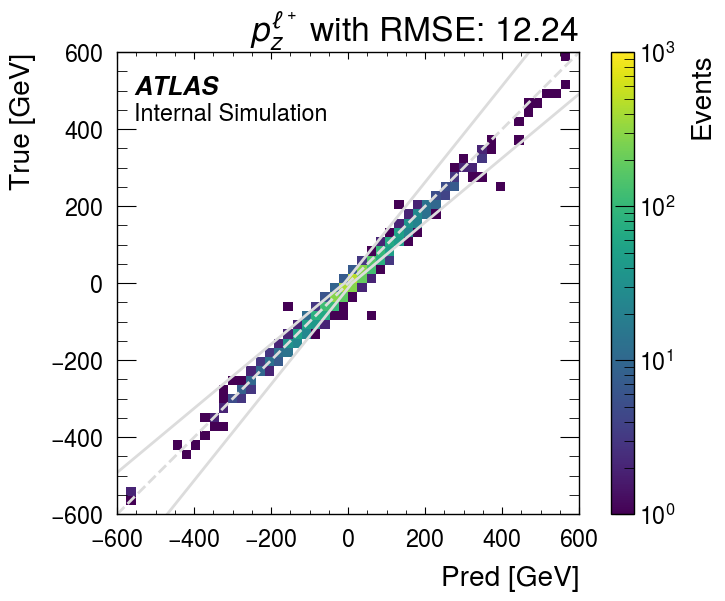

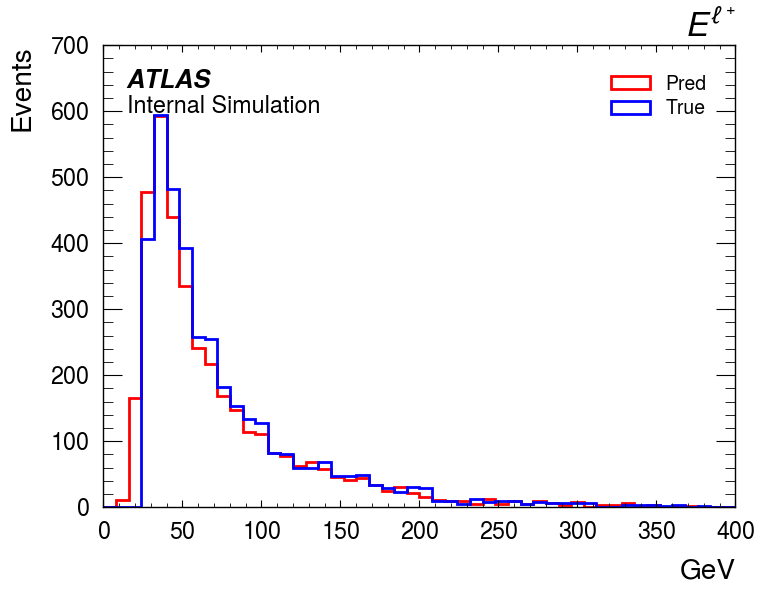

Rel err < 20%: 87.10 %


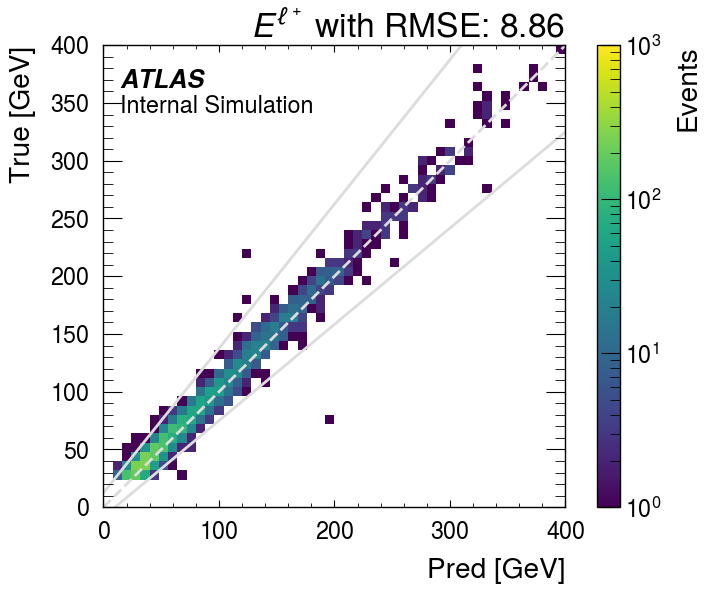

In [16]:
plot_1d_hist(pred_lep0_px, true_lep0_px, "$p^{\ell^+}_x$", bins_edges=np.linspace(-200, 200, 51))
plot_2d_hist(pred_lep0_px, true_lep0_px, "$p^{\ell^+}_x$", bins_edges=np.linspace(-200, 200, 51), log=True)
plot_1d_hist(pred_lep0_py, true_lep0_py, "$p^{\ell^+}_y$", bins_edges=np.linspace(-200, 200, 51))
plot_2d_hist(pred_lep0_py, true_lep0_py, "$p^{\ell^+}_y$", bins_edges=np.linspace(-200, 200, 51), log=True)
plot_1d_hist(pred_lep0_pz, true_lep0_pz, "$p^{\ell^+}_z$", bins_edges=np.linspace(-600, 600, 51))
plot_2d_hist(pred_lep0_pz, true_lep0_pz, "$p^{\ell^+}_z$", bins_edges=np.linspace(-600, 600, 51), log=True)
plot_1d_hist(pred_lep0_e, true_lep0_e, "$E^{\ell^+}$", bins_edges=np.linspace(0, 400, 51))
plot_2d_hist(pred_lep0_e, true_lep0_e, "$E^{\ell^+}$", bins_edges=np.linspace(0, 400, 51), log=True)

# plot_1d_hist(pred_met_px, true_met_px, "$p^{\text{miss}}_x$", bins_edges=np.linspace(-200, 200, 51))
# plot_2d_hist(pred_met_px, true_met_px, "$p^{\text{miss}}_x$", bins_edges=np.linspace(-200, 200, 51), log=True)
# plot_1d_hist(pred_met_py, true_met_py, "$p^{\text{miss}}_y$", bins_edges=np.linspace(-200, 200, 51))
# plot_2d_hist(pred_met_py, true_met_py, "$p^{\text{miss}}_y$", bins_edges=np.linspace(-200, 200, 51), log=True)

In [17]:
# SM

pred_l0_theta = predictions[..., 0]
pred_l0_phi = predictions[..., 1]
pred_l1_theta = predictions[..., 2]
pred_l1_phi = predictions[..., 3]

true_l0_theta = true_labels[..., 0]
true_l0_phi = true_labels[..., 1]
true_l1_theta = true_labels[..., 2]
true_l1_phi = true_labels[..., 3]

In [18]:
def rmse(pred, truth):
	mask = np.isfinite(pred) & np.isfinite(truth)
	if np.sum(mask) != len(pred):
		print(f"Warning: {len(pred) - np.sum(mask)} invalid entries found")
	pred = pred[mask]
	truth = truth[mask]
	return np.sqrt(np.mean((pred - truth) ** 2))

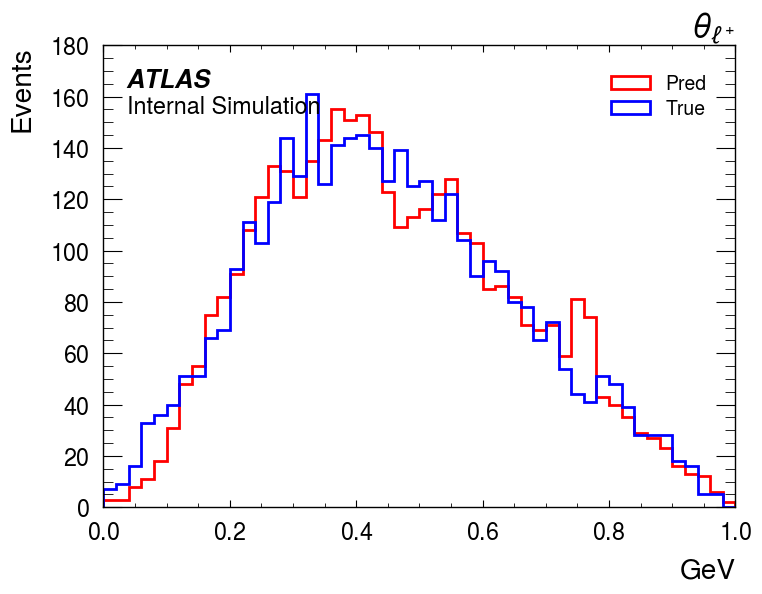

Rel err < 20%: 32.51 %


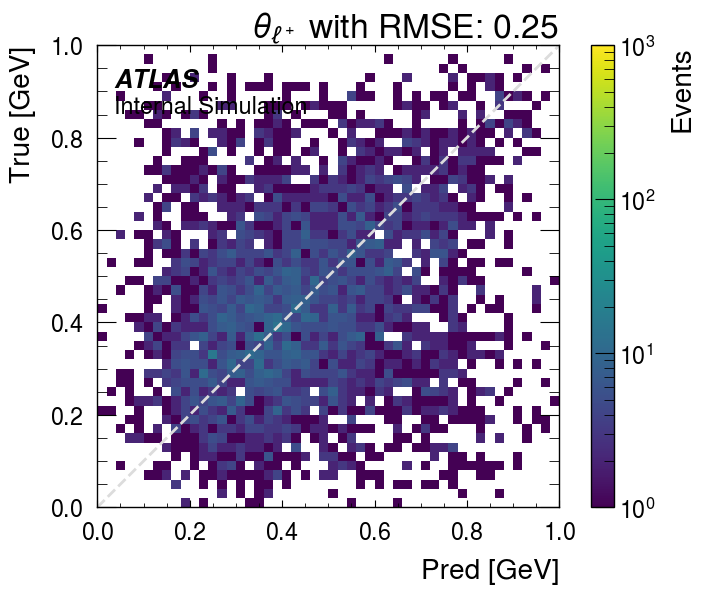

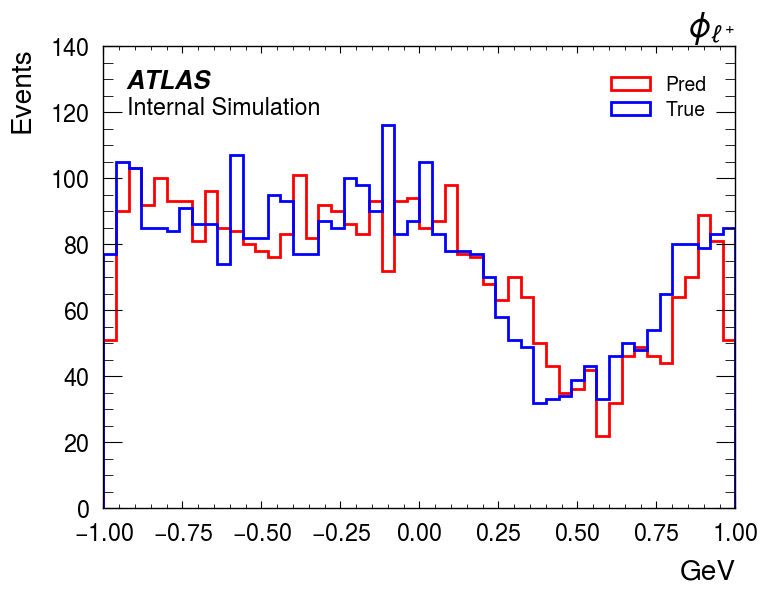

Rel err < 20%: 16.96 %


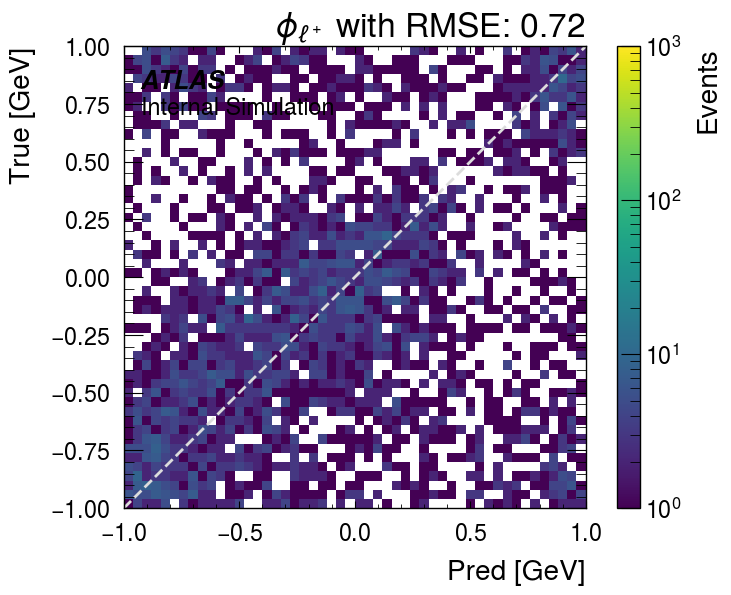

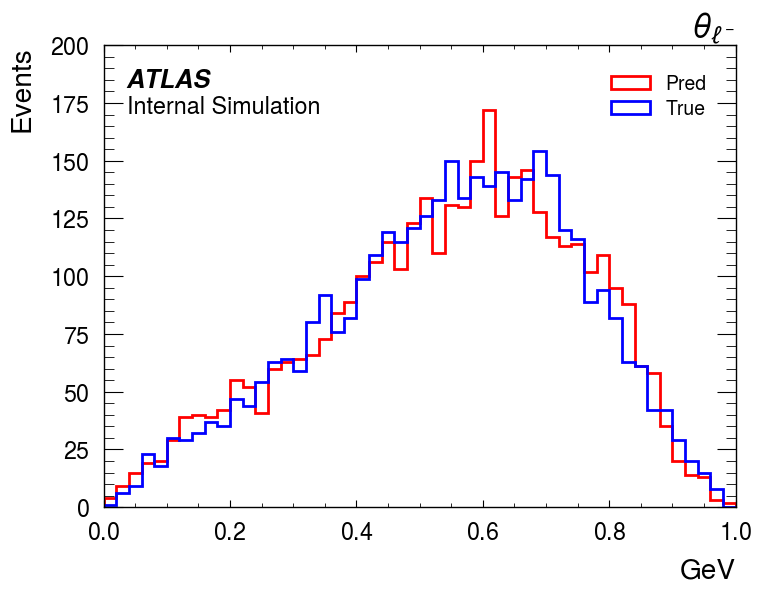

Rel err < 20%: 38.22 %


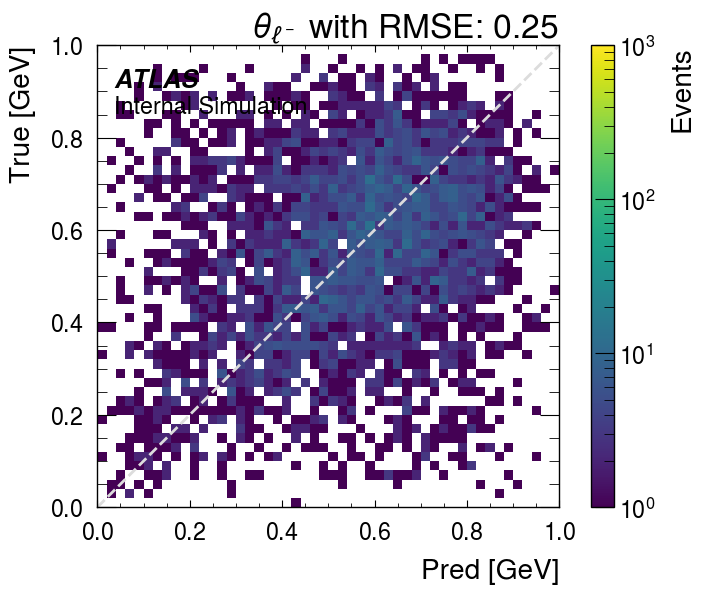

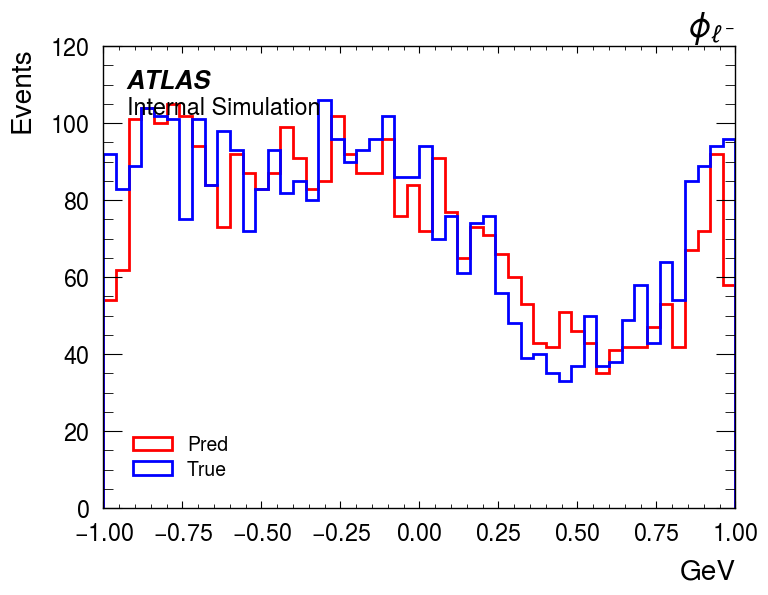

Rel err < 20%: 15.29 %


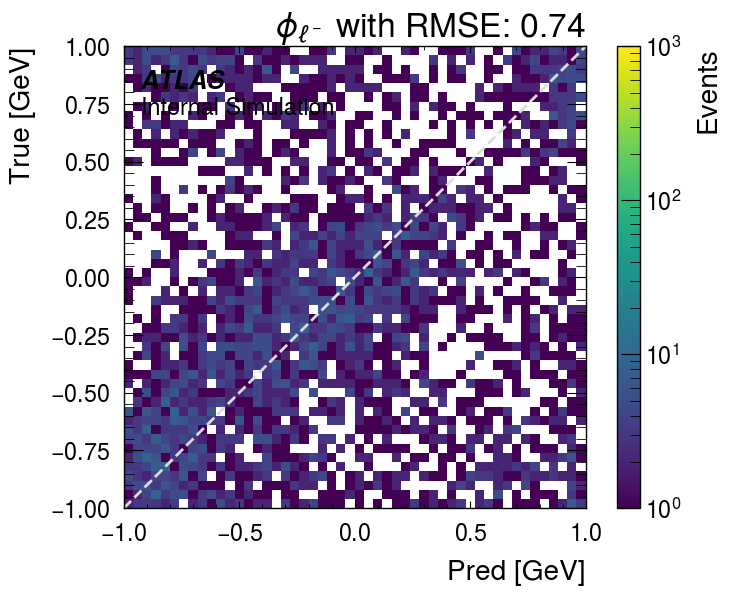

In [19]:
plot_1d_hist(pred_l0_theta, true_l0_theta, "$\\theta_{\ell^+}$", np.linspace(0, 1, 51))
plot_2d_hist(pred_l0_theta, true_l0_theta, "$\\theta_{\ell^+}$", np.linspace(0, 1, 51), log=True)
plot_1d_hist(pred_l0_phi, true_l0_phi, "$\\phi_{\ell^+}$", np.linspace(-1, 1, 51))
plot_2d_hist(pred_l0_phi, true_l0_phi, "$\\phi_{\ell^+}$", np.linspace(-1, 1, 51), log=True)
plot_1d_hist(pred_l1_theta, true_l1_theta, "$\\theta_{\ell^-}$", np.linspace(0, 1, 51))
plot_2d_hist(pred_l1_theta, true_l1_theta, "$\\theta_{\ell^-}$", np.linspace(0, 1, 51), log=True)
plot_1d_hist(pred_l1_phi, true_l1_phi, "$\\phi_{\ell^-}$", np.linspace(-1, 1, 51))
plot_2d_hist(pred_l1_phi, true_l1_phi, "$\\phi_{\ell^-}$", np.linspace(-1, 1, 51), log=True)

In [20]:
def plot_2d_res_hist(pred, truth, name_pos, name_neg, bins_edges=np.linspace(-200, 200, 51), log=False, unit="GeV", color="black", vmax=5e3, savepath=None):
    if log:
        norm = LogNorm(vmin=1, vmax=vmax)
        plt.hist2d(pred, truth, bins=[bins_edges, bins_edges], cmap="viridis", norm=norm)
    else:
        plt.hist2d(pred, truth, bins=[bins_edges, bins_edges], cmap="viridis", vmin=1, vmax=vmax)
    plt.xlabel(rf"$\Delta_\text{{res}}${name_pos} [{unit}]")
    plt.ylabel(rf"$\Delta_\text{{res}}${name_neg} [{unit}]")
    # plt.title(rf"{title}", loc="right")
    txt = hep.atlas.label("Internal Simulation", data=True, loc=0, rlabel="")
    txt[0].set_color(color)
    txt[1].set_color(color)
    plt.tick_params(axis="both", which="major", pad=10) 
    plt.colorbar(label="Events")
    plt.gca().set_aspect("equal", adjustable="box")  # Make plot square
    if savepath is not None:
        plt.savefig(savepath, bbox_inches="tight")
    plt.show()

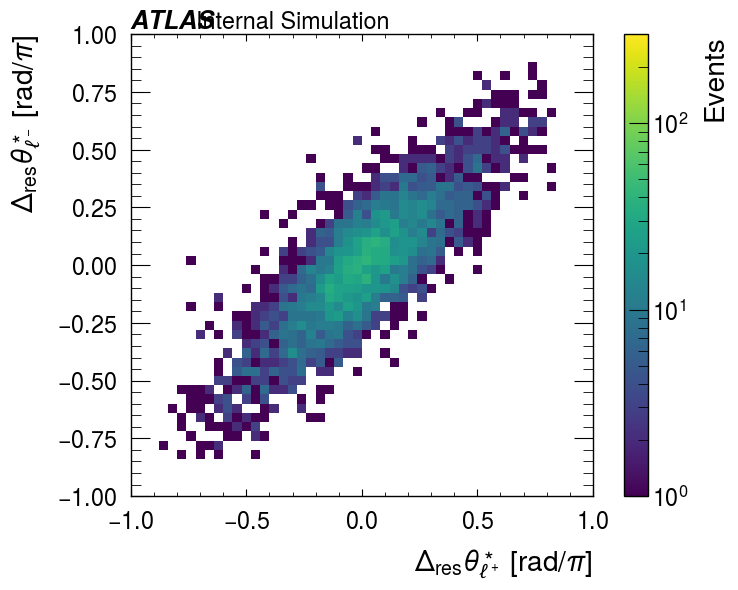

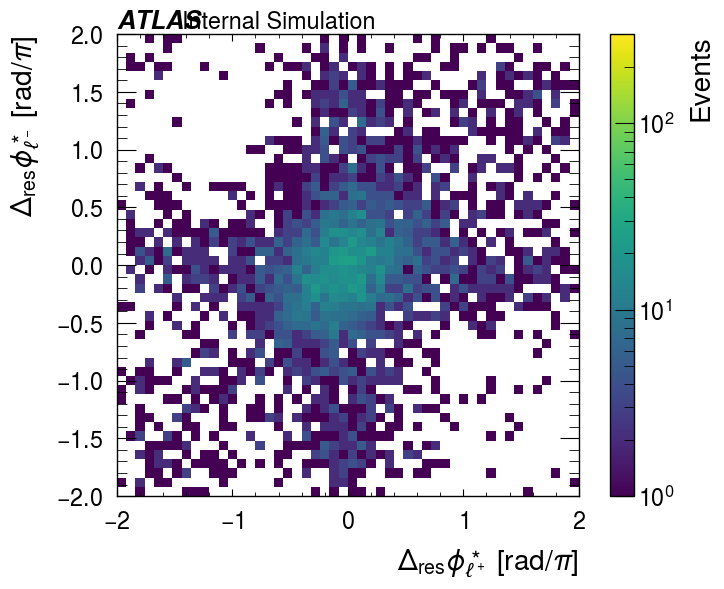

In [21]:
l0_theta_res = pred_l0_theta - true_l0_theta
l1_theta_res = pred_l1_theta - true_l1_theta
plot_2d_res_hist(l0_theta_res, l1_theta_res, name_pos=r"$\theta^\ast_{\ell^+}$", name_neg=r"$\theta^\ast_{\ell^-}$", bins_edges=np.linspace(-1, 1, 51), log=True, unit="rad/$\pi$", color="black", vmax=3e2)

l0_phi_res = pred_l0_phi - true_l0_phi
l1_phi_res = pred_l1_phi - true_l1_phi
plot_2d_res_hist(l0_phi_res, l1_phi_res, name_pos=r"$\phi^\ast_{\ell^+}$", name_neg=r"$\phi^\ast_{\ell^-}$", bins_edges=np.linspace(-2, 2, 51), log=True, unit="rad/$\pi$", color="black", vmax=3e2)

In [22]:
def dphi(phi1, phi2):
    phi_diff = phi1 * np.pi - phi2 * np.pi
    phi_diff = np.where(phi_diff < 0.0, -phi_diff, phi_diff)
    phi_diff = np.where(phi_diff > 2.0 * np.pi, phi_diff - 2.0 * np.pi, phi_diff)
    phi_diff = np.where(phi_diff >= np.pi, 2.0 * np.pi - phi_diff, phi_diff)
    return np.divide(phi_diff, np.pi)

def dtheta(theta1, theta2):
	theta_diff = theta1 * np.pi - theta2 * np.pi
	theta_diff = np.where(theta_diff < 0.0, -theta_diff, theta_diff)
	# theta_diff = np.where(theta_diff > np.pi, theta_diff - np.pi, theta_diff)
	return np.divide(theta_diff, np.pi)

In [23]:
def plot_1d_true_pred_diff(diff, name, bins_edges=np.linspace(-1, 1, 51), unit="rad/$\pi$", color="black", savepath=None):
	plt.hist(diff, bins=bins_edges, linewidth=2, color="green", histtype="step", label=name)
	plt.legend()
	plt.xlabel(f"{name} [{unit}]", loc="right")
	plt.ylabel("Events", loc="top")
	# plt.title(name, loc="right")
	
	txt = hep.atlas.label("Internal Simulation", data=True, loc=2, rlabel="")
	txt[0].set_color(color)
	txt[1].set_color(color)
	plt.tick_params(axis="both", which="major", pad=10)
	if savepath is not None:
		plt.savefig(savepath, bbox_inches="tight")
	plt.show()